# FNOL Claims Intake Agent — LangGraph + Supabase + IMAP

**FNOL** = *First Notice of Loss* — the industry term for "a customer reports an incident."

Multi-agent LangGraph pipeline for auto-insurance claim intake, backed by a real
**Supabase (Postgres)** database instead of an in-memory table, with an optional
**IMAP** inbox poller so claims can come from real customer emails instead of you
typing text into a function call.

## What changed from the last version

| Area | Before | Now |
|---|---|---|
| Storage | In-memory Python dict, wiped on kernel restart | Supabase tables: `customers`, `policies`, `claims` — persists across runs |
| Policy lookup | Hardcoded 4-row SQLite table | Real query against your `policies` table in Supabase |
| Duplicate claims | Second claim on same policy+date got flagged and left as-is | Second claim is **kept**, the *prior* claim(s) get marked `superseded`, and the new one becomes the active record for that incident — still escalated to a human either way |
| Intake | Manual: you call `process_claim(text, email)` | Manual **or** `process_inbox()` — logs into a real mailbox over IMAP, pulls unread claim emails, runs each one through the graph |

**Same as before, unchanged:** everything is still mocked out of the box. Empty
`SUPABASE_URL`/`SUPABASE_KEY` → falls back to an in-memory table. Empty
`IMAP_USER`/`IMAP_PASSWORD` → `process_inbox()` uses one fake sample email instead
of a real mailbox. `MOCK_LLM=true` → every LLM node uses a deterministic stand-in.
Fill in real values in `.env` one at a time and each piece goes live independently.

## Agent graph shape

| Node | Type | What it actually does |
|---|---|---|
| `extract` | **LLM agent** | Turns the free-text claim email into structured fields (policy number, date, location, etc.) |
| `completeness_gate` | hardcoded | Checks the 4 required fields are present — pure `if`, no model involved |
| `followup` | **LLM agent** | Only runs if fields are missing. Drafts an email asking for exactly what's missing, sends it (or dry-run prints it) |
| `policy_checks` | hardcoded | Looks the policy up in Supabase, checks the incident date falls inside the coverage window, checks for prior claims on the same policy+date, calculates the payout — all plain code, no model |
| `weather_agent` | tool-calling agent | Cross-checks the claimed damage type against weather data for that date/location |
| `risk_agent` | **LLM agent** | Reads the claim description and scores how suspicious the phrasing is |
| `decision` | hardcoded | Fixed business rules combine everything above into approve/escalate — a human wrote these thresholds, a model doesn't get a vote here |
| `adjudicator` | **LLM agent** | Reads every other node's output and writes the final plain-English decision report |

Install once: `pip install langgraph openai python-dotenv supabase --break-system-packages`


## Imports + env config

In [21]:
import json
import os
import re
import smtplib
import textwrap
import uuid
from datetime import datetime, timezone
from email.header import decode_header
from email.mime.text import MIMEText
from typing import Any, Dict, List, Optional, TypedDict
import email as email_lib
import imaplib
from supabase import create_client
from langgraph.graph import StateGraph, END

try:
    from dotenv import load_dotenv
    load_dotenv(override=True)  # pulls in .env if present; harmless no-op if it isn't
except ImportError:
    pass  # dotenv is optional -- env vars still work if set some other way

print("Imports OK.")


Imports OK.


## Config

Everything below is overridable via `.env`. Nothing here *requires* a value to
run -- every external system (LLM, Supabase, IMAP, SMTP) has a mocked fallback
so the notebook works with zero setup, and goes live piece by piece as you fill
in real credentials.

In [22]:
def _env_bool(name: str, default: bool) -> bool:
    val = os.getenv(name)
    return default if val is None else val.strip().lower() in ("1", "true", "yes")


MOCK_LLM = _env_bool("MOCK_LLM", True)
DRY_RUN_EMAIL = _env_bool("DRY_RUN_EMAIL", True)

LLM_BASE_URL = os.getenv("LLM_BASE_URL", "https://generativelanguage.googleapis.com/v1beta/openai/")
LLM_API_KEY = os.getenv("LLM_API_KEY", "")
LLM_MODEL = os.getenv("LLM_MODEL", "gemini-2.0-flash")

SMTP_HOST = os.getenv("SMTP_HOST", "smtp.gmail.com")
SMTP_PORT = int(os.getenv("SMTP_PORT", "587"))
SMTP_USER = os.getenv("SMTP_USER", "")
SMTP_PASSWORD = os.getenv("SMTP_PASSWORD", "")

SUPABASE_URL = os.getenv("SUPABASE_URL", "")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

IMAP_HOST = os.getenv("IMAP_HOST", "imap.gmail.com")
IMAP_PORT = int(os.getenv("IMAP_PORT", "993"))
IMAP_USER = os.getenv("IMAP_USER", "")
IMAP_PASSWORD = os.getenv("IMAP_PASSWORD", "")
IMAP_MAILBOX = os.getenv("IMAP_MAILBOX", "INBOX")

AUTO_APPROVE_PAYOUT_LIMIT = 1500.0
RISK_SCORE_ESCALATE_THRESHOLD = 0.3
REQUIRED_CLAIM_FIELDS = ["policy_number", "incident_date", "location", "description"]

_llm_client = None
if not MOCK_LLM and LLM_API_KEY:
    from openai import OpenAI  # lazy import, only needed live
    _llm_client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)

_supabase = None
if SUPABASE_URL and SUPABASE_KEY:
    
    _supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

print(
    f"MOCK_LLM={MOCK_LLM}  DRY_RUN_EMAIL={DRY_RUN_EMAIL}  "
    f"live LLM client: {_llm_client is not None}  live Supabase client: {_supabase is not None}  "
    f"live IMAP configured: {bool(IMAP_USER and IMAP_PASSWORD)}"
)


MOCK_LLM=False  DRY_RUN_EMAIL=False  live LLM client: True  live Supabase client: True  live IMAP configured: True


## Supabase schema

Run this once in the Supabase SQL editor (Project → SQL Editor → New query)
before flipping on live mode. This is the only manual setup step -- the
notebook only ever reads/writes rows, it never creates tables for you.

```sql
create table if not exists customers (
    email text primary key,
    name text
);

create table if not exists policies (
    policy_number text primary key,
    holder_name text not null,
    holder_email text references customers(email),
    address text,
    coverage_limit numeric not null,
    deductible numeric not null,
    start_date date not null,
    end_date date not null
);

create table if not exists claims (
    claim_id text primary key,
    policy_number text references policies(policy_number),
    claimant_email text,
    incident_date date,
    location text,
    description text,
    fault_claimed text,
    damage_type text,
    damage_estimate numeric,
    payout numeric,
    status text,
    decision jsonb,
    coverage_check jsonb,
    risk_notes jsonb,
    weather_check jsonb,
    report text,
    is_duplicate boolean default false,
    superseded_by text,
    source text default 'manual',
    created_at timestamptz default now()
);

-- seed the same 4 sample policies the mock version used, so live mode has
-- something to look up immediately
insert into customers (email, name) values
    ('ravi.sharma@example.com', 'Ravi Sharma'),
    ('ananya.gupta@example.com', 'Ananya Gupta'),
    ('farid.khan@example.com', 'Farid Khan'),
    ('meera.nair@example.com', 'Meera Nair')
on conflict (email) do nothing;

insert into policies (policy_number, holder_name, holder_email, address, coverage_limit, deductible, start_date, end_date) values
    ('POL-1001', 'Ravi Sharma', 'ravi.sharma@example.com', '12 MG Road, Patna, Bihar', 50000, 2000, '2025-01-01', '2026-12-31'),
    ('POL-1002', 'Ananya Gupta', 'ananya.gupta@example.com', '45 Park Street, Kolkata, WB', 30000, 1500, '2025-06-01', '2026-05-31'),
    ('POL-1003', 'Farid Khan', 'farid.khan@example.com', '9 Residency Road, Bengaluru, KA', 75000, 3000, '2024-01-01', '2025-12-31'),
    ('POL-1004', 'Meera Nair', 'meera.nair@example.com', '22 Marine Drive, Mumbai, MH', 40000, 2500, '2025-03-15', '2027-03-14')
on conflict (policy_number) do nothing;
```


## LLM helper

**What this function actually does, line by line:** it's the *only* place in
the whole notebook that talks to the LLM API. Every agent node below calls
through this one function instead of calling the API directly, so there's a
single spot to add retries, logging, or swap providers later.

- If `MOCK_LLM` is on, or no client was built (no API key), it just returns
  the `mock_response` you handed it -- no network call at all.
- Otherwise it sends `system_prompt` + `user_prompt` to the model.
- `expect_json=True` (the default) means it parses the reply as JSON --
  that's for agents like extraction and risk-scoring that must return
  structured data. `expect_json=False` means it hands back the raw text --
  that's for agents writing prose (the follow-up email, the final report).
- If *anything* goes wrong (bad key, network error, the model returned text
  that isn't valid JSON when JSON was expected) it prints why and falls back
  to `mock_response` instead of crashing the graph.

In [23]:
def call_llm(system_prompt: str, user_prompt: str, mock_response: Any, expect_json: bool = True) -> Any:
    if MOCK_LLM or _llm_client is None:
        return mock_response
    try:
        resp = _llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.2,
        )
        raw = resp.choices[0].message.content.strip()
        raw = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.MULTILINE).strip()
        return json.loads(raw) if expect_json else raw
    except Exception as exc:
        print(f"[call_llm] live call failed ({exc!r}) -- falling back to mock.")
        return mock_response


## Database layer

Every function below has the same shape: **if a real Supabase client exists,
hit Supabase. Otherwise, fall back to an in-memory Python list/dict** that
mimics the same table structure. This means the exact same agent code runs
whether or not you've filled in `SUPABASE_URL`/`SUPABASE_KEY` -- the fallback
isn't a separate "demo mode" branch scattered through the graph, it's isolated
entirely to this one cell.

- **`lookup_policy`** -- "what does policy_number look like doesn't require a
  model, does the customer table has policy row?" -- turns
  a policy number into the policy record (holder, address, coverage limit,
  deductible, coverage dates). Pure database read.
- **`check_coverage_window`** -- pure date-math, no database and no AI. Takes
  the incident date and the policy's start/end dates and checks
  `start <= incident_date <= end`. That's the entire function.
- **`find_prior_claims`** -- the duplicate-handling piece. Looks for any
  *other, still-active* (`superseded_by is null`) claim already in the
  database with the same `policy_number` and `incident_date`. It does **not**
  reject anything -- it just returns the list so the graph can decide what to
  do with it (see `decision_node` below).

In [24]:
_mock_customers: Dict[str, Dict[str, Any]] = {}

_mock_policies: Dict[str, Dict[str, Any]] = {
    "POL-1001": {"policy_number": "POL-1001", "holder_name": "Ravi Sharma", "holder_email": "ravi.sharma@example.com",
                 "address": "12 MG Road, Patna, Bihar", "coverage_limit": 50000.0, "deductible": 2000.0,
                 "start_date": "2025-01-01", "end_date": "2026-12-31"},
    "POL-1002": {"policy_number": "POL-1002", "holder_name": "Ananya Gupta", "holder_email": "ananya.gupta@example.com",
                 "address": "45 Park Street, Kolkata, WB", "coverage_limit": 30000.0, "deductible": 1500.0,
                 "start_date": "2025-06-01", "end_date": "2026-05-31"},
    "POL-1003": {"policy_number": "POL-1003", "holder_name": "Farid Khan", "holder_email": "farid.khan@example.com",
                 "address": "9 Residency Road, Bengaluru, KA", "coverage_limit": 75000.0, "deductible": 3000.0,
                 "start_date": "2024-01-01", "end_date": "2025-12-31"},
    "POL-1004": {"policy_number": "POL-1004", "holder_name": "Meera Nair", "holder_email": "meera.nair@example.com",
                 "address": "22 Marine Drive, Mumbai, MH", "coverage_limit": 40000.0, "deductible": 2500.0,
                 "start_date": "2025-03-15", "end_date": "2027-03-14"},
}

_mock_claims: List[Dict[str, Any]] = []  # acts like the `claims` table when Supabase isn't configured


def lookup_policy(policy_number: str) -> Optional[Dict[str, Any]]:
    if _supabase is not None:
        res = _supabase.table("policies").select("*").eq("policy_number", policy_number).limit(1).execute()
        return res.data[0] if res.data else None
    return _mock_policies.get(policy_number)


def check_coverage_window(incident_date_str: str, policy: Dict[str, Any]) -> Dict[str, Any]:
    incident_dt = datetime.strptime(incident_date_str, "%Y-%m-%d").date()
    start_dt = datetime.strptime(policy["start_date"], "%Y-%m-%d").date()
    end_dt = datetime.strptime(policy["end_date"], "%Y-%m-%d").date()
    in_window = start_dt <= incident_dt <= end_dt
    return {
        "in_window": in_window,
        "reason": (
            f"Incident date {incident_date_str} falls within active coverage "
            f"({policy['start_date']} to {policy['end_date']})."
            if in_window else
            f"Incident date {incident_date_str} is OUTSIDE the coverage window "
            f"({policy['start_date']} to {policy['end_date']})."
        ),
    }


def find_prior_claims(policy_number: str, incident_date_str: str, exclude_claim_id: str) -> List[Dict[str, Any]]:
    if _supabase is not None:
        res = (
            _supabase.table("claims").select("*")
            .eq("policy_number", policy_number)
            .eq("incident_date", incident_date_str)
            .neq("claim_id", exclude_claim_id)
            .is_("superseded_by", "null")
            .execute()
        )
        return res.data
    return [
        c for c in _mock_claims
        if c["policy_number"] == policy_number
        and c["incident_date"] == incident_date_str
        and c["claim_id"] != exclude_claim_id
        and not c.get("superseded_by")
    ]


def check_weather(location: str, incident_date_str: str, claimed_damage_type: str) -> Dict[str, Any]:
    """Deterministic synthetic stand-in for a real weather API -- Open-Meteo is
    free and keyless if you want to wire this up to a live source later."""
    day = int(incident_date_str[-2:])
    condition = "clear" if day % 2 == 0 else "storm_with_hail"
    matches = True if claimed_damage_type != "hail" else (condition == "storm_with_hail")
    return {"condition": condition, "source": "MOCK weather", "matches_claim": matches}


def calculate_payout(damage_estimate: float, policy: Dict[str, Any]) -> float:
    covered = min(damage_estimate, policy["coverage_limit"])
    return max(0.0, covered - policy["deductible"])


def db_upsert_customer(email_addr: str, name: Optional[str]) -> None:
    if not email_addr:
        return
    row = {"email": email_addr, "name": name}
    if _supabase is not None:
        _supabase.table("customers").upsert(row, on_conflict="email").execute()
    else:
        _mock_customers[email_addr] = row


def db_insert_claim(record: Dict[str, Any]) -> None:
    if _supabase is not None:
        _supabase.table("claims").insert(record).execute()
    else:
        _mock_claims.append(record)


def db_upsert_claim(record: Dict[str, Any]) -> None:
    """Used by resume_claim -- overwrite the existing row instead of inserting
    a new one, since resuming an incomplete claim isn't a new incident."""
    if _supabase is not None:
        _supabase.table("claims").upsert(record, on_conflict="claim_id").execute()
    else:
        for i, c in enumerate(_mock_claims):
            if c["claim_id"] == record["claim_id"]:
                _mock_claims[i] = record
                return
        _mock_claims.append(record)


def db_get_claim(claim_id: str) -> Optional[Dict[str, Any]]:
    if _supabase is not None:
        res = _supabase.table("claims").select("*").eq("claim_id", claim_id).limit(1).execute()
        return res.data[0] if res.data else None
    return next((c for c in _mock_claims if c["claim_id"] == claim_id), None)


def db_mark_superseded(old_claim_id: str, new_claim_id: str) -> None:
    if _supabase is not None:
        _supabase.table("claims").update({"status": "superseded", "superseded_by": new_claim_id}).eq("claim_id", old_claim_id).execute()
    else:
        for c in _mock_claims:
            if c["claim_id"] == old_claim_id:
                c["status"] = "superseded"
                c["superseded_by"] = new_claim_id


def send_email(to_addr: str, body_with_subject: str) -> None:
    subject_line, _, body = body_with_subject.partition("\n\n")
    subject = subject_line.replace("Subject:", "").strip()

    if DRY_RUN_EMAIL:
        print(f"--- [DRY RUN] would email {to_addr} ---\nSubject: {subject}\n{body}\n--- end email ---")
        return

    msg = MIMEText(body)
    msg["Subject"] = subject
    msg["From"] = SMTP_USER
    msg["To"] = to_addr

    with smtplib.SMTP(SMTP_HOST, SMTP_PORT) as server:
        server.starttls()
        server.login(SMTP_USER, SMTP_PASSWORD)
        server.sendmail(SMTP_USER, [to_addr], msg.as_string())


## Shared graph state

In [25]:
class ClaimState(TypedDict, total=False):
    claim_id: str
    raw_email_text: str
    claimant_email: str
    damage_estimate: float
    source: str

    claim: Dict[str, Any]
    missing_fields: List[str]
    followup_email: str

    policy: Optional[Dict[str, Any]]
    coverage_check: Dict[str, Any]
    prior_claims: List[Dict[str, Any]]
    weather_check: Dict[str, Any]
    risk_notes: Dict[str, Any]
    payout: float

    decision: Dict[str, Any]
    report: str
    status: str


## Agent 1 — Extraction (LLM node: free text → structured JSON)

In [26]:
EXTRACTION_SYSTEM_PROMPT = """You are a claims intake parser for an auto insurer.
Read the claimant's free-text email and return ONLY a JSON object with exactly
these keys: policy_number, incident_date (YYYY-MM-DD or null), location,
description, fault_claimed, damage_type. No prose, no markdown fences."""


def _mock_extract(email_text: str) -> Dict[str, Any]:
    policy_match = re.search(r"POL-\d+", email_text)
    date_match = re.search(r"\d{4}-\d{2}-\d{2}", email_text)
    location_match = re.search(
        r"(?:at|near|outside)\s+([A-Za-z0-9,.\s]+?)(?:\.|,\s*on|\son\s\d{4}|$)", email_text
    )
    return {
        "policy_number": policy_match.group(0) if policy_match else None,
        "incident_date": date_match.group(0) if date_match else None,
        "location": location_match.group(1).strip() if location_match else None,
        "description": email_text.strip(),
        "fault_claimed": "other party" if re.search(r"other (driver|party)", email_text, re.I) else "unclear",
        "damage_type": (
            "hail" if re.search(r"hail", email_text, re.I)
            else "collision" if re.search(r"hit|collision|crash", email_text, re.I)
            else "unspecified"
        ),
    }


def extraction_agent(state: ClaimState) -> Dict[str, Any]:
    extracted = call_llm(
        EXTRACTION_SYSTEM_PROMPT,
        state["raw_email_text"],
        mock_response=_mock_extract(state["raw_email_text"]),
    )
    claim = dict(state.get("claim", {}))
    claim.update({k: v for k, v in extracted.items() if v not in (None, "")})
    return {"claim": claim}


## Completeness gate — hardcoded, no AI

In [27]:
def completeness_gate(state: ClaimState) -> Dict[str, Any]:
    missing = [f for f in REQUIRED_CLAIM_FIELDS if not state["claim"].get(f)]
    return {"missing_fields": missing}


def route_after_completeness(state: ClaimState) -> str:
    return "incomplete" if state["missing_fields"] else "complete"


## Agent 2 — Follow-up drafter (LLM node, only runs on the incomplete branch)

In [28]:
FOLLOWUP_SYSTEM_PROMPT = """You are a claims intake assistant. Write a short,
warm, specific email asking the claimant for exactly the missing information
listed. Do not invent facts about their claim. Return plain text starting
with a 'Subject:' line."""

_FIELD_LABELS = {
    "policy_number": "your policy number",
    "incident_date": "the date the incident happened",
    "location": "where the incident took place",
    "description": "a short description of what happened",
}


def _mock_followup(missing: List[str]) -> str:
    asks = "; ".join(_FIELD_LABELS.get(f, f) for f in missing)
    return (
        "Subject: A couple of details needed to process your claim\n\n"
        f"Hi,\n\nThanks for reporting this. Could you reply with {asks}?\n\n"
        "Once we have that we'll keep processing right away.\n\nBest,\nClaims Team"
    )


def followup_agent(state: ClaimState) -> Dict[str, Any]:
    missing = state["missing_fields"]
    body = call_llm(
        FOLLOWUP_SYSTEM_PROMPT,
        f"Missing fields: {missing}\nKnown so far: {state['claim']}",
        mock_response=_mock_followup(missing),
        expect_json=False,
    )
    send_email(state["claimant_email"], body)
    return {"followup_email": body, "status": "awaiting_info"}


## Policy checks node — hardcoded, no AI

This is the node that actually talks to the database mid-graph: it looks up
the policy, checks the coverage window, and checks for prior claims on the
same policy + incident date (see `find_prior_claims` above). Nothing here
rejects a claim for being a possible duplicate -- that decision is made later,
in `decision_node`, once every other agent has weighed in too.

In [29]:
def policy_checks_node(state: ClaimState) -> Dict[str, Any]:
    claim = state["claim"]
    policy = lookup_policy(claim["policy_number"])
    if policy is None:
        return {"policy": None, "status": "rejected_unknown_policy"}

    coverage_check = check_coverage_window(claim["incident_date"], policy)
    prior_claims = find_prior_claims(claim["policy_number"], claim["incident_date"], state["claim_id"])
    payout = calculate_payout(state.get("damage_estimate", 0.0), policy)
    return {
        "policy": policy,
        "coverage_check": coverage_check,
        "prior_claims": prior_claims,
        "payout": payout,
    }


def route_after_policy_checks(state: ClaimState) -> str:
    return "no_policy" if state.get("policy") is None else "ok"


## Agent 3 — Weather-consistency agent (tool-calling LLM node)

In [30]:
def weather_agent(state: ClaimState) -> Dict[str, Any]:
    claim = state["claim"]
    location = claim.get("location") or state["policy"]["address"]
    weather_check = check_weather(location, claim["incident_date"], claim.get("damage_type", "unspecified"))
    return {"weather_check": weather_check}


## Agent 4 — Suspicious-language / fraud-risk agent (LLM node)

In [31]:
RISK_SYSTEM_PROMPT = """You are a claims fraud-language reviewer. Read the
claim description and return ONLY a JSON object:
{"risk_score": <0.0-1.0>, "notes": "<short reason>"}.
Higher score = more suspicious phrasing or internal inconsistency. Do not
accuse anyone of fraud outright -- just flag language patterns worth a human
look."""

_SUSPICIOUS_PHRASES = ["cash only", "no police report", "totaled it myself", "pay me directly", "don't tell my insurer"]


def _mock_risk(description: str) -> Dict[str, Any]:
    hits = [p for p in _SUSPICIOUS_PHRASES if p in description.lower()]
    score = min(1.0, 0.15 * len(hits) + (0.2 if len(description.split()) < 6 else 0))
    return {
        "risk_score": round(score, 2),
        "notes": f"Flagged phrases: {hits}" if hits else "No obvious red-flag phrasing detected.",
    }


def risk_language_agent(state: ClaimState) -> Dict[str, Any]:
    description = state["claim"].get("description", "")
    risk_notes = call_llm(RISK_SYSTEM_PROMPT, f"Claim description:\n{description}", mock_response=_mock_risk(description))
    return {"risk_notes": risk_notes}


## Decision node — hardcoded thresholds, combines the specialist outputs

This is also where the duplicate/supersede rule lives: if `prior_claims` came
back non-empty from `policy_checks_node`, this claim doesn't get silently
merged or silently dropped -- it gets escalated to a human, with the prior
claim ID(s) named in the reasons, and (after the graph finishes) those prior
rows get their `status` flipped to `superseded` in the database. Both records
stay in the table; only one is "active" at a time.

In [32]:
def decision_node(state: ClaimState) -> Dict[str, Any]:
    payout = state["payout"]
    weather_check = state["weather_check"]
    risk_notes = state["risk_notes"]
    coverage_check = state["coverage_check"]
    prior_claims = state.get("prior_claims", [])

    reasons: List[str] = []
    escalate = False

    if not coverage_check["in_window"]:
        escalate = True
        reasons.append(coverage_check["reason"])
    if prior_claims:
        escalate = True
        prior_ids = ", ".join(c["claim_id"] for c in prior_claims)
        reasons.append(
            f"Supersedes prior claim(s) {prior_ids} filed for the same policy/incident date; "
            "those have been marked superseded and this is now the active claim for that incident."
        )
    if payout > AUTO_APPROVE_PAYOUT_LIMIT:
        escalate = True
        reasons.append(f"Payout ${payout:,.2f} exceeds auto-approve limit of ${AUTO_APPROVE_PAYOUT_LIMIT:,.2f}.")
    if weather_check.get("matches_claim") is False:
        escalate = True
        reasons.append("Claimed damage is inconsistent with historical weather data for that date/location.")
    if risk_notes.get("risk_score", 0) >= RISK_SCORE_ESCALATE_THRESHOLD:
        escalate = True
        reasons.append(f"Language risk score {risk_notes.get('risk_score')} meets/exceeds threshold {RISK_SCORE_ESCALATE_THRESHOLD}.")

    if not reasons:
        reasons.append("In coverage window; no prior claim on file; payout within limit; weather consistent; language risk low.")

    decision = {"decision": "escalate_to_manager" if escalate else "auto_approve", "reasons": reasons}
    status = decision["decision"]
    return {"decision": decision, "status": status}


## Agent 5 — Adjudicator / report writer (LLM node — reads every agent's output)

In [33]:
REPORT_SYSTEM_PROMPT = """You are writing a regulator-ready claims decision
report. Summarise the claim, every check performed, its data source, and the
final decision with explicit reasons. Be factual and concise -- do not add
checks that weren't performed."""


def _mock_report(state: ClaimState) -> str:
    c, p = state["claim"], state["policy"]
    prior = state.get("prior_claims", [])
    prior_line = ", ".join(pc["claim_id"] for pc in prior) if prior else "none"
    return textwrap.dedent(f"""
        CLAIM DECISION REPORT
        Claim ID: {state['claim_id']}
        Generated: {datetime.now(timezone.utc).isoformat()}

        Policy: {c.get('policy_number')} ({p['holder_name']})
        Incident: {c.get('incident_date')} at {c.get('location')}
        Description: {c.get('description')}

        Coverage check: {state['coverage_check']['reason']}
        Prior claims on same policy/date: {prior_line}
        Weather cross-check: {state['weather_check']['condition']} (source: {state['weather_check']['source']}, matches claim: {state['weather_check']['matches_claim']})
        Language risk score: {state['risk_notes']['risk_score']} -- {state['risk_notes']['notes']}
        Calculated payout: ${state['payout']:,.2f}

        DECISION: {state['decision']['decision'].upper()}
        Reason(s): {'; '.join(state['decision']['reasons'])}
    """).strip()


def adjudicator_agent(state: ClaimState) -> Dict[str, Any]:
    bundle = {k: state[k] for k in (
        "claim_id", "claim", "policy", "coverage_check", "prior_claims",
        "weather_check", "risk_notes", "payout", "decision",
    )}
    report = call_llm(REPORT_SYSTEM_PROMPT, json.dumps(bundle, default=str), mock_response=_mock_report(state), expect_json=False)
    return {"report": report}


## Build the graph

In [34]:
def build_graph():
    g = StateGraph(ClaimState)

    g.add_node("extract", extraction_agent)
    g.add_node("completeness_gate", completeness_gate)
    g.add_node("followup", followup_agent)
    g.add_node("policy_checks", policy_checks_node)
    g.add_node("weather_agent", weather_agent)
    g.add_node("risk_agent", risk_language_agent)
    g.add_node("decision", decision_node)
    g.add_node("adjudicator", adjudicator_agent)

    g.set_entry_point("extract")
    g.add_edge("extract", "completeness_gate")

    g.add_conditional_edges(
        "completeness_gate",
        route_after_completeness,
        {"incomplete": "followup", "complete": "policy_checks"},
    )
    g.add_edge("followup", END)

    g.add_conditional_edges(
        "policy_checks",
        route_after_policy_checks,
        {"no_policy": END, "ok": "weather_agent"},
    )

    g.add_edge("weather_agent", "risk_agent")
    g.add_edge("risk_agent", "decision")
    g.add_edge("decision", "adjudicator")
    g.add_edge("adjudicator", END)

    return g.compile()


graph = build_graph()
print("Graph compiled.")


Graph compiled.


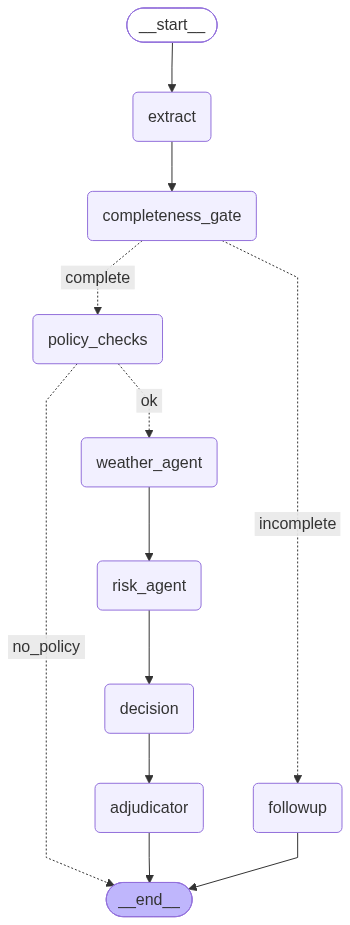

In [35]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Orchestration helpers

`process_claim` runs one claim through the graph, then persists the result:
upserts the customer, inserts the new claim row, and marks any prior claims
on the same incident as `superseded`. `resume_claim` does the same but
*updates* the existing row instead of inserting a new one, since answering a
follow-up isn't a new incident.

In [36]:
def _build_claim_record(state: ClaimState) -> Dict[str, Any]:
    claim = state.get("claim", {})
    return {
        "claim_id": state["claim_id"],
        "policy_number": claim.get("policy_number"),
        "claimant_email": state["claimant_email"],
        "incident_date": claim.get("incident_date"),
        "location": claim.get("location"),
        "description": claim.get("description"),
        "fault_claimed": claim.get("fault_claimed"),
        "damage_type": claim.get("damage_type"),
        "damage_estimate": state.get("damage_estimate", 0.0),
        "payout": state.get("payout"),
        "status": state.get("status"),
        "decision": state.get("decision"),
        "coverage_check": state.get("coverage_check"),
        "risk_notes": state.get("risk_notes"),
        "weather_check": state.get("weather_check"),
        "report": state.get("report"),
        "is_duplicate": bool(state.get("prior_claims")),
        "superseded_by": None,
        "source": state.get("source", "manual"),
    }


def _persist_result(state: ClaimState, is_resume: bool = False) -> None:
    if state.get("policy"):
        db_upsert_customer(state["claimant_email"], state["policy"].get("holder_name"))

    record = _build_claim_record(state)
    if is_resume:
        db_upsert_claim(record)
    else:
        db_insert_claim(record)

    for prior in state.get("prior_claims", []):
        db_mark_superseded(prior["claim_id"], state["claim_id"])


def process_claim(
    raw_email_text: str,
    claimant_email: str,
    damage_estimate: float = 0.0,
    claim_id: Optional[str] = None,
    source: str = "manual",
) -> Dict[str, Any]:
    claim_id = claim_id or f"CLM-{uuid.uuid4().hex[:8].upper()}"
    state: ClaimState = {
        "claim_id": claim_id,
        "raw_email_text": raw_email_text,
        "claimant_email": claimant_email,
        "damage_estimate": damage_estimate,
        "claim": {},
        "status": "new",
        "source": source,
    }
    result = graph.invoke(state)
    _persist_result(result, is_resume=False)
    return result


def resume_claim(claim_id: str, followup_email_text: str, damage_estimate: Optional[float] = None) -> Dict[str, Any]:
    prior = db_get_claim(claim_id)
    if prior is None:
        raise ValueError(f"No existing claim found for {claim_id} -- did the first pass finish and persist?")

    state: ClaimState = {
        "claim_id": claim_id,
        "raw_email_text": followup_email_text,
        "claimant_email": prior["claimant_email"],
        "damage_estimate": damage_estimate if damage_estimate is not None else (prior.get("damage_estimate") or 0.0),
        "claim": {
            k: prior[k] for k in
            ["policy_number", "incident_date", "location", "description", "fault_claimed", "damage_type"]
            if prior.get(k)
        },
        "status": "new",
        "source": prior.get("source", "manual"),
    }
    result = graph.invoke(state)
    _persist_result(result, is_resume=True)
    return result


def print_review_queue() -> None:
    if _supabase is not None:
        res = (
            _supabase.table("claims").select("claim_id,status,policy_number")
            .in_("status", ["awaiting_info", "escalate_to_manager"])
            .is_("superseded_by", "null")
            .execute()
        )
        rows = res.data
    else:
        rows = [
            c for c in _mock_claims
            if c.get("status") in ("awaiting_info", "escalate_to_manager") and not c.get("superseded_by")
        ]
    if not rows:
        print("Review queue is empty.")
        return
    for r in rows:
        print(f"- {r['claim_id']}: status={r['status']}  policy={r.get('policy_number')}")


## IMAP inbox intake

`fetch_new_claim_emails()` logs into a real mailbox, pulls unread messages,
and returns them **without** marking them read (`BODY.PEEK[]`) so a crash
mid-run doesn't silently lose an email -- a message only gets marked seen
after `process_inbox()` has successfully run it through the graph.

If `IMAP_USER`/`IMAP_PASSWORD` are empty, it skips the real connection
entirely and returns one canned sample email, so `process_inbox()` is safe to
run with zero setup, same as everything else here.

**Note on running this "in production":** a notebook cell is fine for you to
trigger manually or demo live, but a real deployment would run
`process_inbox()` on a schedule (cron, a small script + systemd timer, Airflow,
etc.) rather than a human re-running a cell. That's a deployment detail
outside the notebook itself, not a code change.

In [37]:
def _extract_plain_text(msg) -> str:
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain" and not part.get("Content-Disposition"):
                payload = part.get_payload(decode=True)
                return payload.decode(errors="ignore") if payload else ""
        return ""
    payload = msg.get_payload(decode=True)
    return payload.decode(errors="ignore") if payload else ""


def _mock_inbox() -> List[Dict[str, Any]]:
    return [{
        "uid": b"mock-1",
        "from": "ravi.sharma@example.com",
        "subject": "Car hit while parked",
        "body": (
            "Hi, my policy is POL-1001. My car was hit while parked outside "
            "12 MG Road, Patna on 2026-08-14. The other driver left before I "
            "could get their details."
        ),
    }]


def fetch_new_claim_emails(max_emails: int = 10):
    """Returns (connection_or_None, list_of_messages). Caller must call
    mark_seen(conn, uid) per message after processing, then close the connection."""
    if not (IMAP_USER and IMAP_PASSWORD):
        print("IMAP not configured (IMAP_USER/IMAP_PASSWORD empty) -- using a mock inbox.")
        return None, _mock_inbox()

    conn = imaplib.IMAP4_SSL(IMAP_HOST, IMAP_PORT)
    conn.login(IMAP_USER, IMAP_PASSWORD)
    conn.select(IMAP_MAILBOX)
    _, data = conn.search(None, "UNSEEN")
    ids = data[0].split()[:max_emails]

    messages = []
    for eid in ids:
        _, msg_data = conn.fetch(eid, "(BODY.PEEK[])")
        raw = msg_data[0][1]
        msg = email_lib.message_from_bytes(raw)
        from_addr = email_lib.utils.parseaddr(msg.get("From", ""))[1]
        subject_raw, enc = decode_header(msg.get("Subject", ""))[0]
        subject = subject_raw.decode(enc or "utf-8", errors="ignore") if isinstance(subject_raw, bytes) else subject_raw
        messages.append({"uid": eid, "from": from_addr, "subject": subject, "body": _extract_plain_text(msg)})
    return conn, messages


def mark_seen(conn, uid) -> None:
    if conn is not None:
        conn.store(uid, "+FLAGS", "\\Seen")


def process_inbox(max_emails: int = 10) -> List[Dict[str, Any]]:
    conn, messages = fetch_new_claim_emails(max_emails=max_emails)
    results = []
    for m in messages:
        record = process_claim(m["body"], m["from"], source="imap")
        results.append(record)
        mark_seen(conn, m["uid"])
    if conn is not None:
        conn.logout()
    return results


## Test scenarios

Run these first with everything mocked to confirm the wiring works, then flip
`.env` values on one at a time (Supabase first, then LLM, then IMAP/SMTP) and
re-run -- each piece goes live independently.

### Scenario A — clean, complete claim (expected: `auto_approve`)

In [41]:
email_a = (
    "Hi, my policy is POL-1001. My car was hit while parked outside 12 MG Road, "
    "Patna on 2026-08-14. The other driver left before I could get their details."
)
record_a = process_claim(email_a, "ravi.sharma@example.com", damage_estimate=2200.0)
print("STATUS:", record_a["status"])
print()
print(record_a["report"])


STATUS: escalate_to_manager

### Claims Decision Report: CLM-7890477D

**Claim Summary**
*   **Claimant:** Ravi Sharma
*   **Policy Number:** POL-1001
*   **Incident Date:** 2026-08-14
*   **Incident Description:** Hit-and-run collision while parked at 12 MG Road, Patna.
*   **Claimed Fault:** Not at fault.

**Checks Performed**
| Check | Result | Data Source |
| :--- | :--- | :--- |
| **Coverage Validity** | Active | Policy POL-1001 (2025-01-01 to 2026-12-31) |
| **Prior Claims** | None | Internal Claims Database |
| **Weather Verification** | Clear | MOCK Weather Service |
| **Risk Assessment** | Score: 0.4 | Internal Risk Analysis Engine |

**Decision: Escalate to Manager**

**Reasons for Decision**
1.  **Risk Threshold Breach:** The claim received a risk score of 0.4, which exceeds the internal threshold of 0.3 for automated processing.
2.  **Insufficient Documentation:** The claim narrative lacks critical supporting details, including the specific time of the incident, precise loc

### Scenario B — incomplete claim, then resumed (expected: `awaiting_info` → resolved)

In [ ]:
email_b_incomplete = "Hi, policy POL-1002, someone hit my car."  # no date, no location

record_b = process_claim(email_b_incomplete, "ananya.gupta@example.com")
print("STATUS AFTER FIRST PASS:", record_b["status"])
print("MISSING FIELDS:", record_b["missing_fields"])


In [ ]:
email_b_followup = "It happened on 2026-03-15 at 45 Park Street, Kolkata."

record_b = resume_claim(record_b["claim_id"], email_b_followup, damage_estimate=900.0)
print("STATUS AFTER RESUME:", record_b["status"])
print()
print(record_b["report"])


### Scenario C — inconsistent / high-value claim (expected: `escalate_to_manager`)

In [ ]:
email_c = (
    "Policy POL-1004. Hail storm damaged my car badly near 22 Marine Drive, Mumbai "
    "on 2026-08-12, cash only please, no police report needed, totaled it myself basically."
)
record_c = process_claim(email_c, "meera.nair@example.com", damage_estimate=30000.0)
print("STATUS:", record_c["status"])
print("RISK NOTES:", record_c["risk_notes"])
print("WEATHER CHECK:", record_c["weather_check"])
print()
print(record_c["report"])


### Scenario D — a second claim on the same incident (expected: prior claim gets superseded)

This is the duplicate-handling behaviour: submit another claim for the same
policy + incident date as Scenario A. Both rows stay in the database — the
first one gets `status = superseded`, the second becomes the active one.

In [ ]:
email_d = (
    "Following up on my POL-1001 claim -- turns out the damage is worse than I "
    "first thought. Same incident, outside 12 MG Road, Patna, on 2026-08-14."
)
record_d = process_claim(email_d, "ravi.sharma@example.com", damage_estimate=5000.0)
print("STATUS:", record_d["status"])
print("PRIOR CLAIMS FOUND:", [c["claim_id"] for c in record_d.get("prior_claims", [])])
print()
print(record_d["report"])

print()
print("Original claim after being superseded:")
print(db_get_claim(record_a["claim_id"]))


### Scenario E — pull claims straight from an inbox

In [43]:
inbox_results = process_inbox()
for r in inbox_results:
    print(f"{r['claim_id']}: status={r['status']}")


CLM-AC1ACF56: status=awaiting_info
CLM-574BA17C: status=awaiting_info
CLM-AD234502: status=awaiting_info
CLM-6D711E17: status=awaiting_info
CLM-58EE1E48: status=awaiting_info
CLM-028E88CE: status=awaiting_info
CLM-C485F360: status=awaiting_info
CLM-D1D2D995: status=awaiting_info
CLM-C898162B: status=awaiting_info
CLM-C496D67E: status=awaiting_info


### Manager review queue

In [ ]:
print_review_queue()

## Going live — checklist

1. **Supabase**: create a project, run the SQL schema above in the SQL editor,
   then put the project URL and an API key into `SUPABASE_URL` / `SUPABASE_KEY`
   in `.env`. (Use the `service_role` key for a backend like this, not the
   public `anon` key — the service key isn't subject to row-level-security
   policies, which matters since this code writes on the customer's behalf.)
2. **LLM**: `LLM_API_KEY` + `MOCK_LLM=false`.
3. **Email sending**: `SMTP_USER` / `SMTP_PASSWORD` (a Gmail **App Password**,
   not your login password) + `DRY_RUN_EMAIL=false`.
4. **IMAP intake**: `IMAP_USER` / `IMAP_PASSWORD` (same app-password style
   credential) + `IMAP_HOST` if you're not on Gmail.
5. Restart the kernel after editing `.env` — `load_dotenv(override=True)`
   only takes effect from a fresh process.
6. For an actual production deployment, `process_inbox()` should be triggered
   on a schedule outside the notebook (cron / systemd timer / Airflow), and
   the Supabase service key should live in a secrets manager, not a plaintext
   `.env` file on a laptop.
